### Математическое описание алгоритма Linear SVM (Soft Margin)

В данной реализации заложена математическая логика линейного метода опорных векторов (Linear SVM) с мягким отступом (Soft Margin) и обучением с помощью стохастического градиентного спуска (SGD).

---

#### 1. Целевая функция (Функция потерь / Loss Function)
Алгоритм одновременно максимизирует ширину разделяющей полосы ($L_2$-регуляризация) и минимизирует ошибки классификации на обучающей выборке (**Hinge Loss**):

$$L(w, b) = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \max\left(0, 1 - y_i (w^T x_i + b)\right)$$

Где:
* $\frac{1}{2} \|w\|^2 = \frac{1}{2} \sum_{j=1}^{m} w_j^2$ — штраф за слишком большие веса (`0.5 * np.dot(w, w)`). Чем меньше веса, тем шире разделяющая полоса.
* $y_i (w^T x_i + b)$ — функциональный отступ (margin) для $i$-го объекта.
* $\max(0, 1 - \text{margin})$ — функция потерь Hinge Loss. Она равна $0$, если объект лежит дальше границы полосы со своего края, и растет линейно, если объект нарушает эту границу.
* $C$ — гиперпараметр (`self.C`), регулирующий баланс между шириной полосы и ошибками.

---

#### 2. Условие отступа (Margin Condition)
Во внутреннем цикле для каждого отдельного объекта $i$ проверяется условие корректной классификации с учетом безопасного расстояния:

$$y_i (w^T x_i + b) \ge 1$$

* В коде: `if y[i] * ((X[i] @ self.weight) + self.intercept) >= 1:`

---

#### 3. Субградиенты функции потерь (Subgradients)
Так как функция Hinge Loss имеет излом (не дифференцируема в точке $1$), для оптимизации используются субградиенты ($\nabla$). Они вычисляются отдельно для каждого объекта в зависимости от выполнения условия отступа.

##### Случай А: Объект классифицирован верно и находится вне полосы ($y_i (w^T x_i + b) \ge 1$)
Вклад в ошибку равен нулю. Градиент берется только от регуляризатора:
$$\nabla_w L = w$$
$$\nabla_b L = 0$$

##### Случай Б: Объект нарушает отступ или классифицирован неверно ($y_i (w^T x_i + b) < 1$)
Объект штрафует модель, поэтому к градиенту регуляризации добавляется градиент от функции Hinge Loss:
$$\nabla_w L = w - C \cdot y_i \cdot x_i$$
$$\nabla_b L = - C \cdot y_i$$

---

#### 4. Шаг градиентного спуска (SGD)
Параметры модели ($w$ и $b$) обновляются в сторону, противоположную направлению субградиента:

$$w^{(new)} = w^{(old)} - \eta \cdot \nabla_w L$$
$$b^{(new)} = b^{(old)} - \eta \cdot \nabla_b L$$

Где:
* $\eta$ — скорость обучения (`self.learning_rate`).

---

#### 5. Критерий ранней остановки (Early Stopping)
Модель прекращает обучение до достижения `max_iter`, если изменение полной функции потерь между двумя соседними эпохами становится незначительным:

$$\left| L^{(epoch - 1)} - L^{(epoch)} \right| < \epsilon$$

Где:
* $\epsilon$ — порог сходимости (`self.stop_gr`).

---

#### 6. Функция предсказания (Inference)
Для классификации новых точек вычисляется знак геометрического расстояния до разделяющей плоскости:

$$\hat{y} = \text{sign}(w^T x + b)$$

Так как на выходе получается значение из множества $\{-1, 1\}$, алгоритм трансформирует его обратно в исходный формат пользователя $\{0, 1\}$:

$$f(\hat{y}) = \begin{cases} 1, & \text{если } \hat{y} = 1 \\ 0, & \text{если } \hat{y} = -1 \end{cases}$$


In [74]:
import numpy as np
import pandas as pd

class LinearSVM:
    """
    Реализует алгоритм Метода Опорных Векторов (SVM) для задач бинарной классификации.
    
    Модель строит линейную комбинацию входных признаков и максимизирует разделяющий 
    зазор между классами с использованием функции потерь Hinge Loss. Обучение 
    выполняется методом стохастического градиентного спуска (SGD) с поддержкой 
    критерия ранней остановки и L2-регуляризации (Soft Margin).
    
    Аргументы инициализации:
    ------------------------
    max_iter : int, default=3000
        Максимальное количество эпох градиентного спуска для обучения модели.
    learning_rate : float, default=0.001
        Скорость обучения (шаг градиентного спуска), контролирующая величину обновления весов.
    C : float, default=1.0
        Коэффициент штрафа за ошибку классификации. Управляет балансом между шириной 
        разделяющего зазора и количеством ошибок на обучающей выборке. Меньшие значения 
        усиливают L2-регуляризацию.
    stop_gr : float, default=1e-5
        Критерий ранней остановки. Обучение прерывается, если абсолютное изменение 
        сглаженной функции потерь Hinge Loss между эпохами становится меньше этого значения.
    mean_feature : bool, default=False
        Позволяет управлять усреднением по признакам.
        При True ослабляется влияние штрафа за ошибку, что делает регуляризацию l2 доминируюшей, 
        ширина разделяющей полосы становится важнее, чем правильное разделение классов
        Если SGD=True (режим SGDClassifier): не делит градиент.
        Если SGD=False (режим LinearSVC): усредняет градиент по всей выборке.
    
    Основные методы:
    ----------------
    fit(X, y)
        Запускает цикл стохастического градиентного спуска для настройки весов и сдвига 
        на обучающей выборке.
    predict(X)
        Предсказывает финальные метки классов (0 или 1) для объектов из переданной 
        матрицы признаков X.
    
    Внутренние атрибуты:
    --------------------
    weight : numpy.ndarray
        Вектор подобранных весов модели. Длина вектора равна количеству признаков в матрице X.
    intercept : float
        Свободный коэффициент модели (сдвиг/bias).
    loss_history : list
        Список значений функции потерь Hinge Loss на каждой эпохе для мониторинга обучения.
    epoch : int
        Фактическое количество эпох, которое потребовалось модели до завершения обучения.
    
    Свойства:
    ----------------------
    plot_loss
        Свойство класса, которое визуализирует график падения функции потерь по ходу эпох обучения.
    get_support_vectors
        Свойство класса, позволяющее получить кортеж из 3 значений: 
        индексов, координат точек и истинных классов опорных векторов.
    """
    def __init__(self, max_iter = 3000, learning_rate = 0.001, C = 1.0, stop_gr = 1e-5, SGD = False):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.C = C
        self.stop_gr = stop_gr
        self.SGD = SGD

    def mean_feature(self, X):
        """ Позволяет отключить усреднения по признакам."""
        if self.SGD:
            return 1
        return len(X)
    
    def fit(self, X, y):

        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
        self.weight = np.zeros(X.shape[1])
        self.intercept = 0

        self.loss_history = []

        X = np.array(X)
        y = np.where(y == 0, -1,1)

        for epoch in range(self.max_iter):
            for i in range(len(X)):
                if y[i] * ((X[i] @ self.weight) + self.intercept) >= 1:  # HingeLoss
                    dw = self.weight / self.mean_feature(X)
                    db = 0
                else:
                    dw = self.weight/self.mean_feature(X) - self.C * y[i] * X[i]
                    db = -self.C * y[i]/self.mean_feature(X)
            
                self.weight -= self.learning_rate * dw
                self.intercept -= self.learning_rate * db
                
            margins = y * (X @ self.weight + self.intercept)
            loss = 0.5 * np.dot(self.weight, self.weight) + self.C * np.sum(np.maximum(0, 1 - margins))
            self.loss_history.append(loss)

            if epoch > 1 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.stop_gr:
                self.epoch = epoch+1
                break
                
        self.epoch = epoch
        return self
        
    def predict(self,X):
        pred = np.sign((X @ self.weight) + self.intercept)
        return np.where(pred == -1, 0, 1)

    @property
    def plot_loss(self):
        return pd.DataFrame(self.loss_history).plot()

    @property
    def get_support_vectors(self):
        """Возвращает кортеж: (индекс, координата точек, истинные классы)"""
        y_scaled = np.where(self.y_train == 0, -1, 1)   
        margins = y_scaled * (self.X_train @ self.weight + self.intercept)
        support_indx = np.where(margins <= 1.0001)[0]
        return support_indx, self.X_train[support_indx], self.y_train[support_indx]

Точность модели: 100.0%
Найдено опорных векторов: 5


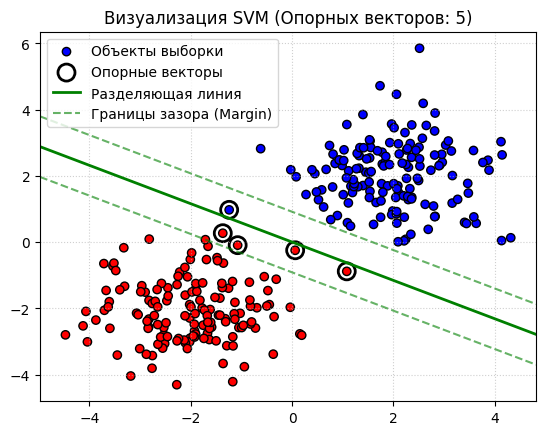

In [75]:
import matplotlib.pyplot as plt

np.random.seed(42)

n = 150

X_class0 = np.random.randn(n, 2) + np.array([2, 2])
X_class1 = np.random.randn(n, 2) + np.array([-2, -2])
X = np.vstack((X_class0, X_class1))
y = np.array([0]*n + [1]*n)

svm = LinearSVM().fit(X, y)

predictions = svm.predict(X)
print(f"Точность модели: {np.mean(predictions == y) * 100}%")

v_indices, sv_coords, sv_labels = svm.get_support_vectors
print(f"Найдено опорных векторов: {len(sv_coords)}")

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', label='Объекты выборки')

plt.scatter(sv_coords[:, 0], sv_coords[:, 1], s=n, facecolors='none', 
            edgecolors='black', linewidths=2, label='Опорные векторы')

# Автоматически определяем диапазон для красивой отрисовки линий
x_points = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)


w = svm.weight
b = svm.intercept

y_points = -(w[0] * x_points + b) / w[1]  # Центральная разделяющая линия w0*x + w1*y + b = 0 => y = -(w0*x + b) / w1

y_margin_upper = -(w[0] * x_points + b - 1) / w[1]  # Верхняя 
y_margin_lower = -(w[0] * x_points + b + 1) / w[1]  # Нижняя граница зазора

plt.plot(x_points, y_points, color='green', linestyle='-', linewidth=2, label='Разделяющая линия')
plt.plot(x_points, y_margin_upper, 'g--', alpha=0.6, label='Границы зазора (Margin)')
plt.plot(x_points, y_margin_lower, 'g--', alpha=0.6)

plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.title(f"Визуализация SVM (Опорных векторов: {len(sv_coords)})")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


Прошло циклов обучения 419


<Axes: >

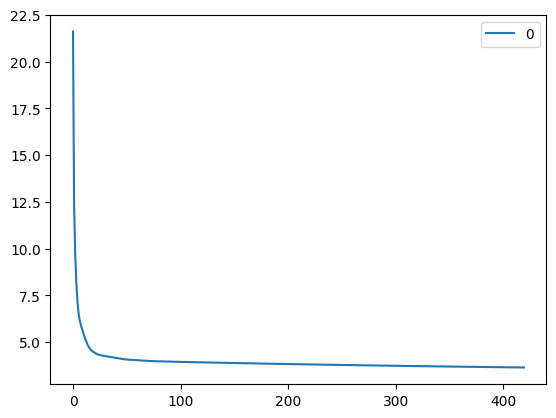

In [76]:
print(f'Прошло циклов обучения {svm.epoch}')
svm.plot_loss

In [77]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

X, y = make_blobs(n_samples=500, centers=2, random_state=42, cluster_std=3.5)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

custom_svm = LinearSVM(max_iter=5000, learning_rate=0.1, C=1.0, stop_gr=1e-6, SGD=False).fit(X_scaled, y)

sklearn_svm = LinearSVC(loss='hinge', C=1.0, random_state=42).fit(X_scaled, y)

custom_preds = custom_svm.predict(X_scaled)
sklearn_preds = sklearn_svm.predict(X_scaled)

custom_acc = accuracy_score(y, custom_preds)
sklearn_acc = accuracy_score(y, sklearn_preds)

In [78]:
print(f"Количество эпох до остановки SVM: {custom_svm.epoch}")
print(f"Кастомный SVM Accuracy: {custom_acc:.4f}")
print(f"Sklearn SVM Accuracy:   {sklearn_acc:.4f}")
print(f"Кастомные веса:      {custom_svm.weight}")
print(f"Sklearn веса:        {sklearn_svm.coef_[0]}")
print(f"Кастомный интерцепт: {custom_svm.intercept:.4f}")
print(f"Sklearn интерцепт:   {sklearn_svm.intercept_[0]:.4f}")

Количество эпох до остановки SVM: 4999
Кастомный SVM Accuracy: 0.9240
Sklearn SVM Accuracy:   0.9140
Кастомные веса:      [ 1.4634649  -1.67555524]
Sklearn веса:        [ 1.67337311 -1.53275567]
Кастомный интерцепт: 0.0792
Sklearn интерцепт:   0.0672


Алгоритм прошел 4999 эпох


<Axes: >

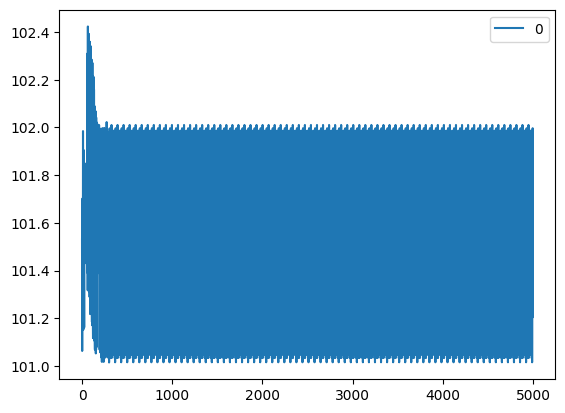

In [79]:
print(f'Алгоритм прошел {custom_svm.epoch} эпох')
custom_svm.plot_loss

### Cравнение кастомной модели с Методом опорных векторов через градиентный спуск SGDClassifier из sklearn

In [80]:
from sklearn.linear_model import SGDClassifier

sklearn_sgd = SGDClassifier(
    loss='hinge',              # Функция потерь SVM
    penalty='l2',              # Регуляризация квадрата весов
    alpha=1.0,                 # Задает математический баланс (аналог C=1.0)
    learning_rate='constant',  # Отключаем адаптивный шаг sklearn
    eta0=0.001,                # Аналог learning_rate
    max_iter=30000,            
    shuffle=False,             # Отключаем перемешивание (в костомной модели его нет)
    tol=None                   # аналогк stop_gr
)
sklearn_sgd.fit(X_scaled, y)

custom_sgd = LinearSVM(SGD=True).fit(X_scaled, y)

custom_sgd_preds = custom_sgd.predict(X_scaled)
sklearn_sgd_preds = sklearn_sgd.predict(X_scaled)

custom_sgd_acc = accuracy_score(y, custom_sgd_preds)
sklearn_sgd_acc = accuracy_score(y, sklearn_sgd_preds)

In [81]:
print(f'''
Кастомный SGD Accuracy: {custom_sgd_acc:.4f}
Sklearn SGD Accuracy:   {sklearn_sgd_acc:.4f}

Веса sgd из sklearn {sklearn_sgd.coef_[0]}
Веса кастомной модели {custom_sgd.weight}

Отступ sgd из sklearn {sklearn_sgd.intercept_[0]:.4f}
Отступ костомной модели {custom_sgd.intercept:.4f}''')


Кастомный SGD Accuracy: 0.9220
Sklearn SGD Accuracy:   0.9220

Веса sgd из sklearn [ 0.44662916 -0.42920024]
Веса кастомной модели [ 0.44662916 -0.42920024]

Отступ sgd из sklearn -0.0100
Отступ костомной модели -0.0100
